# **1 – Introduction**
## Principal Component Analysis (PCA) - Beginner Guide

In this notebook you will learn:

✅ What is PCA

✅ Why PCA is Needed

✅ What is Dimensionality Reduction

✅ How PCA Works

✅ Principal Components

✅ Explained Variance

✅ Applying PCA using Scikit-Learn

✅ Visualizing PCA Results

Target Audience:

- Beginners
- Data Analyst Aspirants
- Data Science Learners


# **2 – Real-Life Example**
## Understanding PCA with a School Example

Imagine a student has marks in:

- Mathematics
- Science
- English
- History
- Geography

Total Features = 5

Instead of storing all 5 subjects separately,
we can create a new feature called:

"Overall Academic Performance"

This new feature summarizes most of the information.

This is the basic idea behind PCA.

# **3 – What Problem Does PCA Solve?**
## Why Do We Need PCA?

Large datasets may contain many features.

Example:

- Weight
- Horsepower
- Displacement
- Cylinders
- Acceleration

Some features contain similar information.

PCA helps us:

✅ Reduce the number of features

✅ Remove redundancy

✅ Speed up machine learning

✅ Improve visualization

# **4 – Setting up the data**

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import pandas as pd

car_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/auto_mpg_binarised.csv')

car_data.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name,mpg_high
0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu,0
1,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320,0
2,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite,0
3,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst,0
4,8,302.0,140.0,3449.0,10.5,70,1,ford torino,0


In [15]:
numeric_columns = ['displacement', 'horsepower', 'weight', 'acceleration']
car_data[numeric_columns].head()


,displacement,horsepower,weight,acceleration
0,307.0,130.0,3504.0,12.0
1,350.0,165.0,3693.0,11.5
2,318.0,150.0,3436.0,11.0
3,304.0,150.0,3433.0,12.0
4,302.0,140.0,3449.0,10.5


# **4 – Why Scale Before PCA?**
## Important Rule

Always scale data before PCA.

Example:

- Weight = 3500

- Horsepower = 120

- Acceleration = 15

Weight is much larger.

Without scaling,
PCA will give too much importance to Weight.

Therefore:

Scaling → PCA

# **5 – Feature Scaling**

In [16]:
from sklearn.preprocessing import StandardScaler

standardscaler = StandardScaler()
scaled_features = standardscaler.fit_transform(
                      car_data[numeric_columns]
                  )
scaled_features

array([[ 1.0906037 ,  0.66919608,  0.63086987, -1.29549834],
       [ 1.5035143 ,  1.58659918,  0.85433297, -1.47703779],
       [ 1.19623199,  1.19342642,  0.55047045, -1.65857724],
       ...,
       [-0.56103873, -0.53653371, -0.79858454, -1.4407299 ],
       [-0.70507731, -0.66759129, -0.40841088,  1.10082237],
       [-0.71467988, -0.58895674, -0.29608816,  1.39128549]])

# **6 – Apply PCA**

In [17]:
from sklearn.decomposition import PCA

pca = PCA()

principal_components = pca.fit_transform(scaled_features)

principal_components

array([[ 1.78388485, -0.58813342, -0.40298114, -0.15169936],
       [ 2.68784016, -0.57025988,  0.07856791, -0.36540895],
       [ 2.22697986, -0.92547433, -0.09482768, -0.29017142],
       ...,
       [-0.42769924, -1.717854  , -0.40681864,  0.12892787],
       [-1.38528272,  0.61403241,  0.13455143,  0.08528414],
       [-1.40565211,  0.90918223,  0.25735615,  0.11080853]])

# **7 – What Happened?**
## What does PCA do?

Original Data

4 Features

↓

PCA

↓

Principal Components

- PC1 → displacement
- PC2 → horsepower
- PC3 → weight
- PC4 → acceleration

These new columns contain the important information
from the original dataset.

In [18]:
pca_dataframe = pd.DataFrame(
    principal_components,
    columns = ['PC1', 'PC2', 'PC3', 'PC4']
    )

pca_dataframe.head()

,PC1,PC2,PC3,PC4
0,1.783885,-0.588133,-0.402981,-0.151699
1,2.687840,-0.570260,0.078568,-0.365409
2,2.226980,-0.925474,-0.094828,-0.290171
3,2.008983,-0.647364,0.061418,-0.265058
4,2.083026,-1.106254,-0.293022,-0.109014


# **8 – Explained Variance**

## Explained Variance

Explained variance tells us how much information
each Principal Component contains.

Example:

PC1 = 60%

PC2 = 25%

PC3 = 10%

PC4 = 5%

Total = 100%

PC1 contains the most useful information.

In [19]:
pca.explained_variance_ratio_

array([0.80065771, 0.16337756, 0.02225683, 0.0137079 ])

# **9 – Visualize Explained Variance**

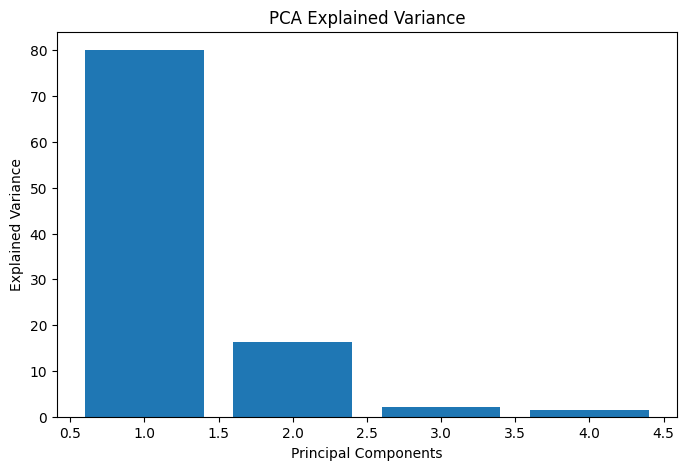

In [20]:
import matplotlib.pyplot as plt

variance_ratio = pca.explained_variance_ratio_*100

plt.figure(
    figsize=(8,5)
)

plt.bar(
    range(1, len(variance_ratio)+1),
    variance_ratio
)

plt.xlabel('Principal Components')
plt.ylabel('Explained Variance')
plt.title('PCA Explained Variance')

plt.show()

# **10 – Cumulative Variance**


Suppose:

PC1 = 60%

PC2 = 20%

PC3 = 10%

Cumulative Variance:

PC1 = 60%

PC1 + PC2 = 80%

PC1 + PC2 + PC3 = 90%

If 90% of information is captured,
we may keep only the first 3 components.

In [21]:
import numpy as np

cumulative_variance = np.cumsum(
    variance_ratio*100
)

cumulative_variance

array([ 8006.57710774,  9640.35272397,  9862.92099759, 10000.        ])

# **11 – PCA with 2 Components**

For our dataset, the first two features such as displacement and horsepower holds high contribution, so consider PC1 and PC2

In [22]:
pca_2 = PCA(n_components=2)
principal_components_2 = pca_2.fit_transform(scaled_features)
principal_components_2.shape


(398, 2)

# **12 – Create 2D PCA Dataset**

In [23]:
pca_2_data = pd.DataFrame(
    principal_components_2,
    columns = ['PC1', 'PC2']
    )
pca_2_data.head()

,PC1,PC2
0,1.783885,-0.588133
1,2.687840,-0.570260
2,2.226980,-0.925474
3,2.008983,-0.647364
4,2.083026,-1.106254


# **13 – PCA Visualization**

/tmp/ipykernel_906/626430257.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc=(1.05, 0))


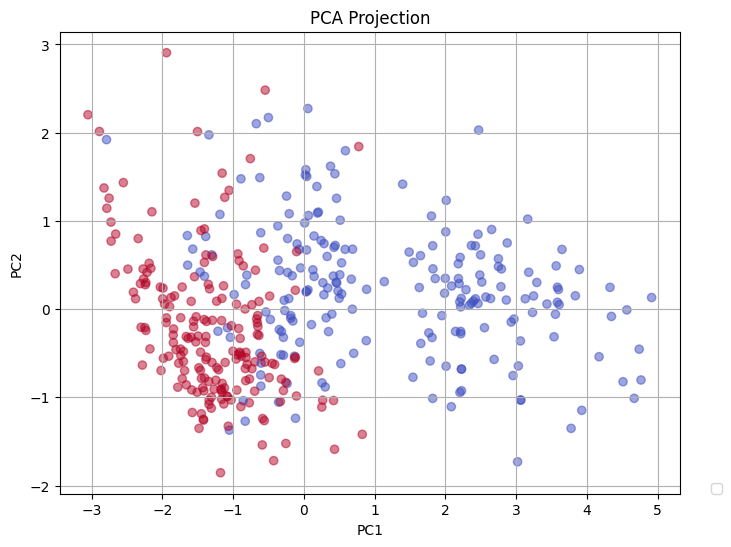

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    pca_2_data["PC1"],
    pca_2_data["PC2"],
    alpha = 0.5,
    c=car_data["mpg_high"],
    cmap="coolwarm",
)

plt.legend(loc=(1.05, 0))
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.grid()
plt.show()

# **14 – Key Observations**

## What Did PCA Achieve?

Original Dataset

4 Features

↓

PCA

↓

2 Features

- PC1
- PC2

Most of the important information
is still preserved.

- Less data
- Faster training
- Simpler visualization

# **15 – Practice Exercises**
## Practice Exercises

Exercise 1

Apply PCA with 3 components.

--------------------------------

Exercise 2

Calculate explained variance.

--------------------------------

Exercise 3

Calculate cumulative variance.

--------------------------------

Exercise 4

Visualize the first two components.

--------------------------------

Exercise 5

Find how many components are required
to retain 95% information.

# **16 – Interview Questions**

1. What is PCA?

2. Why is PCA used?

3. What is dimensionality reduction?

4. What is a Principal Component?

5. Why should data be scaled before PCA?

6. What is explained variance?

7. What is cumulative variance?

8. How do you choose the number of components?

9. Is PCA supervised or unsupervised?

10. What are the advantages of PCA?


# **17 - Summary**
## What You Learned

✅ PCA

✅ Dimensionality Reduction

✅ Principal Components

✅ Explained Variance

✅ Cumulative Variance

✅ PCA Visualization

✅ PCA with Scikit-Learn

Next Notebook:

05_PCA_Mini_Project.ipynb

***One-Line Summary***

PCA reduces the number of features in a dataset while preserving most of the important information, making machine learning models faster and easier to work with.